In [58]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

In [59]:
df = pd.read_csv('data/clownmitmuetze_with_features_engineered_for_model.csv')

In [60]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_inaccuracy',
       'is_mistake', 'is_blunder', 'eval_unified', 'complexity_material_norm',
       'eval_volatility_norm', 'time_pressure_norm',
       'material_time_pressure_int', 'time_eval_volatility_int',
       'move_number_norm', 'late_endgame_int', 'cumulative_time_pressure',
       'color_white', 'time_left_ratio_clipped', 'time_left_bin'],
      dtype='

In [61]:
df = df.drop(['time_left_bin', 'is_blunder', 'is_mistake'], axis = 1)

In [62]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_inaccuracy',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [63]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop('is_inaccuracy', axis=1)
y = df['is_inaccuracy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.concat([X_train, y_train], axis=1)

In [64]:
X_train.shape

(57019, 42)

In [65]:
y_train.shape

(57019,)

In [66]:
y_train[y_train == 1].sum()

np.int64(2112)

In [67]:
X_test.shape

(14255, 42)

In [68]:
y_test[y_test == 1].sum()

np.int64(528)

In [69]:
X_test.to_csv('model_data/X_test_inaccuracy.csv', index=False)
y_test.to_csv('model_data/y_test_inaccuracy.csv', index=False)

In [70]:
# Numeric columns
numeric_columns = [
    col for col in df.columns
    if df[col].nunique() != 2 and col not in ['is_inaccuracy', 'is_mistake', 'is_blunder']
]
numeric_columns

['move_number',
 'increment_sec',
 'time_left_sec',
 'time_spent_sec',
 'time_left_ratio',
 'eval_volatility',
 'pieces_remaining',
 'material_density',
 'num_minor_pieces',
 'num_rooks',
 'num_queens',
 'num_pawns',
 'complexity_material_score',
 'avg_time_spent_per_move',
 'time_spent_ratio',
 'eval_unified',
 'complexity_material_norm',
 'eval_volatility_norm',
 'time_pressure_norm',
 'material_time_pressure_int',
 'time_eval_volatility_int',
 'move_number_norm',
 'late_endgame_int',
 'cumulative_time_pressure',
 'time_left_ratio_clipped']

In [71]:
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("q1:", Q1, "q3:", Q3, "IQR:", IQR, "lower_bound:", lower_bound, "upper_bound:", upper_bound)
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

for i in numeric_columns:
    print(i, ":", len(find_outliers_iqr(train_df[i])))

q1: 11.0 q3: 31.0 IQR: 20.0 lower_bound: -19.0 upper_bound: 61.0
move_number : 964
q1: 3.0 q3: 9.0 IQR: 6.0 lower_bound: -6.0 upper_bound: 18.0
increment_sec : 2507
q1: 169.79 q3: 536.67 IQR: 366.88 lower_bound: -380.53 upper_bound: 1086.9899999999998
time_left_sec : 3184
q1: 2.84 q3: 17.52 IQR: 14.68 lower_bound: -19.18 upper_bound: 39.54
time_spent_sec : 5197
q1: 0.3776444444444444 q3: 0.9888958333333334 IQR: 0.6112513888888891 lower_bound: -0.5392326388888893 upper_bound: 1.905772916666667
time_left_ratio : 1073
q1: 9.93310961716756 q3: 56.46828018159104 IQR: 46.53517056442348 lower_bound: -59.86964622946766 upper_bound: 126.27103602822626
eval_volatility : 5646
q1: 17.0 q3: 29.0 IQR: 12.0 lower_bound: -1.0 upper_bound: 47.0
pieces_remaining : 0
q1: 0.53125 q3: 0.90625 IQR: 0.375 lower_bound: -0.03125 upper_bound: 1.46875
material_density : 0
q1: 3.0 q3: 7.0 IQR: 4.0 lower_bound: -3.0 upper_bound: 13.0
num_minor_pieces : 0
q1: 2.0 q3: 4.0 IQR: 2.0 lower_bound: -1.0 upper_bound: 7.0


In [72]:
# Set option to display all rows
pd.set_option('display.max_rows', None)

In [73]:

train_df['move_number'].value_counts().sort_index(ascending = False)

move_number
106       1
105       1
102       1
100       2
99        2
98        3
97        2
96        3
95        2
94        2
93        1
92        3
91        4
90        4
89        4
88        5
87        4
86        7
85        8
84        9
83       12
82       10
81       13
80       21
79       21
78       23
77       26
76       29
75       31
74       29
73       34
72       39
71       39
70       46
69       52
68       50
67       59
66       56
65       61
64       69
63       79
62       97
61       99
60      116
59      117
58      136
57      155
56      149
55      174
54      193
53      211
52      234
51      250
50      285
49      299
48      331
47      350
46      378
45      407
44      468
43      494
42      519
41      554
40      595
39      625
38      664
37      708
36      763
35      792
34      835
33      906
32      960
31      968
30     1015
29     1061
28     1107
27     1152
26     1196
25     1253
24     1330
23     1360
22     1424
21  

In [74]:

train_df['increment_sec'].value_counts().sort_index(ascending = False)

increment_sec
180       47
90        50
45       186
40       274
35       215
30       787
25       549
20       399
18        69
17       102
16       197
15      3522
14       235
13       120
12      1151
11       265
10      5722
9        944
8       5117
7       1450
6       1265
5      14958
4        602
3       6843
2       1970
1        326
0       9654
Name: count, dtype: int64

In [75]:
train_df['time_spent_sec'].value_counts().sort_index(ascending = False)

time_spent_sec
1215.40       1
998.16        1
975.40        1
938.06        1
823.95        1
796.00        1
708.84        1
620.16        1
608.56        1
582.72        1
580.92        1
574.83        1
536.32        1
532.56        1
532.36        1
518.11        1
518.04        1
509.84        1
507.04        1
484.56        1
481.28        1
479.04        1
472.52        1
468.51        1
467.16        1
461.80        1
456.00        1
451.16        1
447.36        1
447.32        1
445.28        1
445.12        1
429.40        1
421.84        1
419.56        1
412.00        1
404.64        1
400.43        1
394.92        1
394.80        1
394.20        1
394.04        1
390.72        1
388.08        1
385.84        1
382.80        1
382.72        1
382.60        1
381.55        1
378.72        1
378.60        1
376.11        1
370.60        1
364.24        1
360.80        1
356.76        1
352.96        1
349.44        1
346.60        1
339.28        1
337.80        1
337.68   

In [76]:
train_df['avg_time_spent_per_move'].value_counts().sort_index(ascending = False)

avg_time_spent_per_move
269.270000     6
125.689091    17
106.309677    23
101.315676    28
96.545882     28
90.675238     33
87.528750     13
78.106667     29
77.429730     26
73.380645     18
71.500000     15
69.272222     43
68.690000      6
67.498462     17
67.300000     23
65.008222     39
61.410000     10
60.643421     59
57.745000     23
56.654545     22
56.242222     13
56.147917     20
55.349583     34
55.179697     27
55.045714     21
53.826000     15
53.676579     31
53.227368     14
52.276923     10
52.113333     14
51.894286     19
50.389643     22
50.185946     26
48.300000     21
47.017143     15
46.942069     23
46.587143     22
46.290000     24
45.861818     27
45.246786     22
44.582381     16
44.405714     10
44.219722     30
43.728000     22
43.530204     40
43.230345     21
42.364684     57
42.278814     46
42.172093     34
42.091739     14
41.805714     14
41.628939     55
41.166190     24
41.141538     15
39.795484     21
39.641200     18
39.160870     16
38.9108

In [77]:
train_df['eval_unified'].value_counts().sort_index(ascending = False)

eval_unified
 16955.400000     156
 16929.537500      80
 16903.675000      70
 16877.812500      77
 16851.950000      69
 16826.087500      64
 16800.225000      63
 16774.362500      48
 16748.500000      32
 16722.637500      33
 16696.775000      18
 16670.912500      20
 16645.050000      19
 16619.187500      11
 16593.325000      12
 16567.462500       5
 16541.600000       7
 16515.737500       5
 16489.875000       2
 16464.012500       2
 16438.150000       5
 16412.287500       1
 16386.425000       4
 16360.562500       3
 16334.700000       5
 16308.837500       1
 16257.112500       2
 16231.250000       1
 16205.387500       1
 16179.525000       1
 16127.800000       2
 16101.937500       1
 15998.487500       1
 15946.762500       1
 15895.037500       1
 15714.000000       1
 15414.000000       1
 15265.000000       1
 14565.000000       1
 14361.000000       1
 9605.000000        1
 8308.000000        3
 8189.000000        1
 8133.000000        1
 7826.000000       

In [78]:
df.columns

Index(['move_number', 'increment_sec', 'time_left_sec', 'time_spent_sec',
       'time_left_ratio', 'eval_volatility', 'pieces_remaining',
       'material_density', 'num_minor_pieces', 'num_rooks', 'num_queens',
       'num_pawns', 'complexity_material_score', 'white_castled_king',
       'white_castled_queen', 'black_castled_king', 'black_castled_queen',
       'queen_present', 'is_opening', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'is_inaccuracy',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

Don't remove any outliers since these are all representative of data

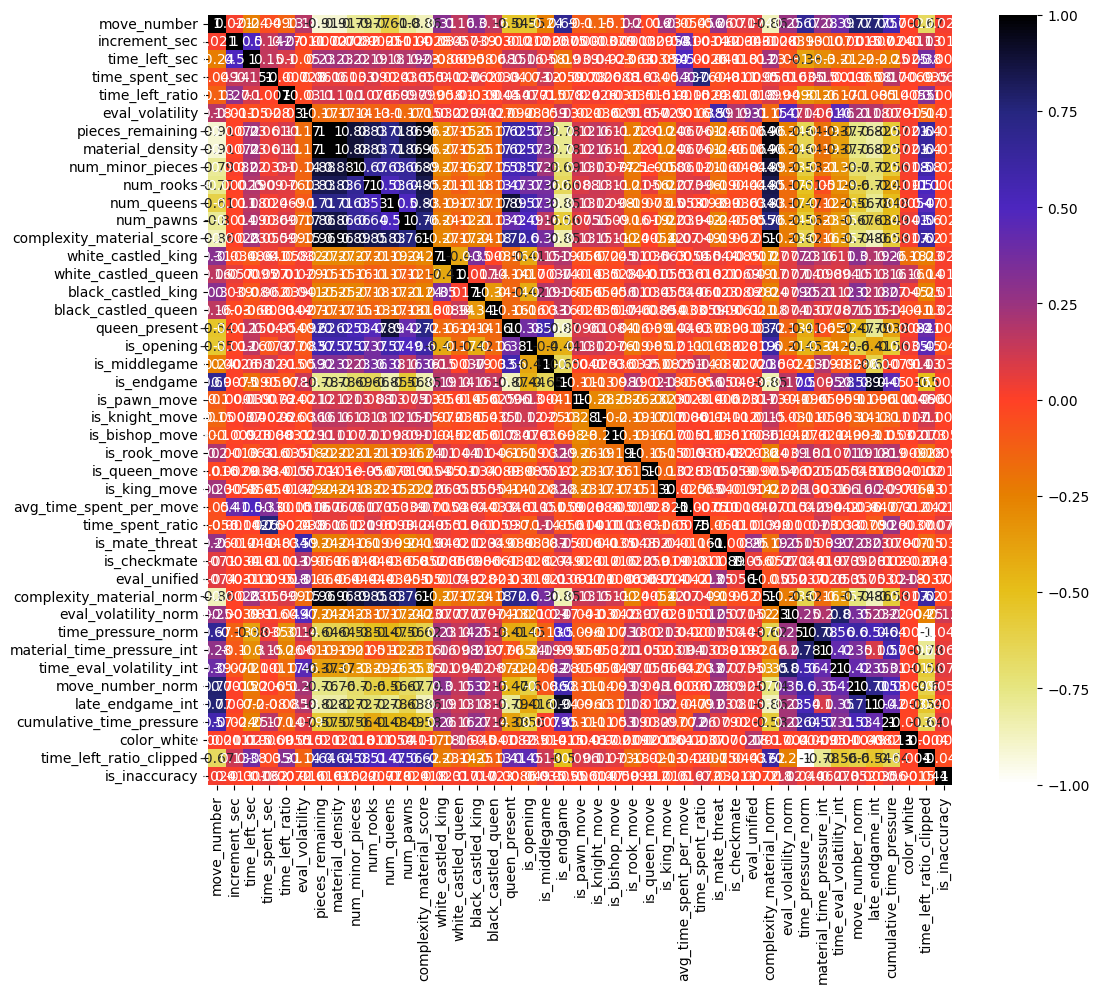

In [79]:
#Using Pearson Correlation
plt.figure(figsize=(12,10))
cor = train_df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [80]:
train_df.corr()

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,...,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure,color_white,time_left_ratio_clipped,is_inaccuracy
move_number,1.000000,0.020659,-0.239618,-0.049373,-0.125855,0.178166,-0.913410,-0.913410,-0.789591,-0.773062,...,0.250561,0.670657,0.276905,0.393937,0.773845,0.766037,0.565752,0.002112,-0.670657,0.023857
increment_sec,0.020659,1.000000,0.501403,0.144137,0.273480,-0.010914,-0.007205,-0.007205,0.008236,-0.000249,...,-0.003920,-0.131439,-0.101102,-0.070708,0.001470,0.006958,-0.024429,0.001127,0.131439,0.012612
time_left_sec,-0.239618,0.501403,1.000000,0.152381,0.101276,-0.049590,0.230455,0.230455,0.215440,0.192872,...,-0.080747,-0.380857,-0.298903,-0.213433,-0.217302,-0.200968,-0.246484,0.025429,0.380857,-0.001346
time_spent_sec,-0.049373,0.144137,0.152381,1.000000,-0.006983,-0.028472,0.060611,0.060611,0.033241,0.089816,...,0.015745,0.035211,0.150791,-0.001124,0.006543,-0.079932,0.173007,0.006886,-0.035211,0.062064
time_left_ratio,-0.125855,0.273480,0.101276,-0.006983,1.000000,-0.030353,0.107526,0.107526,0.101866,0.075710,...,-0.048789,-0.308060,-0.255087,-0.168766,-0.104784,-0.084672,-0.144737,-0.005500,0.308060,-0.007156
eval_volatility,0.178166,-0.010914,-0.049590,-0.028472,-0.030353,1.000000,-0.171613,-0.171613,-0.137930,-0.133187,...,0.474165,0.138958,0.060806,0.460741,0.211255,0.183584,0.078836,0.015186,-0.138958,-0.016307
pieces_remaining,-0.913410,-0.007205,0.230455,0.060611,0.107526,-0.171613,1.000000,1.000000,0.884828,0.833671,...,-0.243363,-0.636487,-0.188914,-0.369601,-0.758404,-0.824385,-0.565257,0.021190,0.636487,-0.016035
material_density,-0.913410,-0.007205,0.230455,0.060611,0.107526,-0.171613,1.000000,1.000000,0.884828,0.833671,...,-0.243363,-0.636487,-0.188914,-0.369601,-0.758404,-0.824385,-0.565257,0.021190,0.636487,-0.016035
num_minor_pieces,-0.789591,0.008236,0.215440,0.033241,0.101866,-0.137930,0.884828,0.884828,1.000000,0.666999,...,-0.227411,-0.582071,-0.207012,-0.329540,-0.697507,-0.716810,-0.561813,0.017756,0.582071,-0.021787
num_rooks,-0.773062,-0.000249,0.192872,0.089816,0.075710,-0.133187,0.833671,0.833671,0.666999,1.000000,...,-0.166220,-0.513986,-0.051377,-0.289460,-0.601735,-0.721499,-0.413041,0.011187,0.513986,-0.000767


In [81]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in the absolute coefficient value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [82]:
corr_features = correlation(train_df, 0.8)
len(set(corr_features))

11

In [83]:
corr_features

{'complexity_material_norm',
 'complexity_material_score',
 'is_endgame',
 'late_endgame_int',
 'material_density',
 'num_minor_pieces',
 'num_pawns',
 'num_rooks',
 'pieces_remaining',
 'queen_present',
 'time_left_ratio_clipped'}

Determine columns to drop

In [84]:
X_train = X_train.drop([
'move_number',
'eval_volatility',
 'complexity_material_score',
 'time_left_ratio',
 'is_opening',
 'material_density',
 'num_minor_pieces',
 'num_pawns',
 'num_queens',
 'num_rooks',
 'pieces_remaining'], axis=1) 

In [85]:
X_train.columns

Index(['increment_sec', 'time_left_sec', 'time_spent_sec',
       'white_castled_king', 'white_castled_queen', 'black_castled_king',
       'black_castled_queen', 'queen_present', 'is_middlegame', 'is_endgame',
       'is_pawn_move', 'is_knight_move', 'is_bishop_move', 'is_rook_move',
       'is_queen_move', 'is_king_move', 'avg_time_spent_per_move',
       'time_spent_ratio', 'is_mate_threat', 'is_checkmate', 'eval_unified',
       'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [86]:
from sklearn.feature_selection import mutual_info_classif
# determine the mutual information
mutual_info = mutual_info_classif(X_train, y_train, random_state=42)
mutual_info

array([0.00107985, 0.0006268 , 0.00388529, 0.01060989, 0.00047645,
       0.0091482 , 0.00094767, 0.01031298, 0.00584904, 0.00571796,
       0.00249912, 0.        , 0.00054547, 0.        , 0.00144082,
       0.00061472, 0.00451544, 0.00430865, 0.        , 0.00032605,
       0.00758766, 0.00235218, 0.05243739, 0.00076056, 0.00309375,
       0.01466489, 0.00325592, 0.00075407, 0.00360556, 0.00665484,
       0.00198024])

In [87]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

eval_volatility_norm          0.052437
time_eval_volatility_int      0.014665
white_castled_king            0.010610
queen_present                 0.010313
black_castled_king            0.009148
eval_unified                  0.007588
color_white                   0.006655
is_middlegame                 0.005849
is_endgame                    0.005718
avg_time_spent_per_move       0.004515
time_spent_ratio              0.004309
time_spent_sec                0.003885
cumulative_time_pressure      0.003606
move_number_norm              0.003256
material_time_pressure_int    0.003094
is_pawn_move                  0.002499
complexity_material_norm      0.002352
time_left_ratio_clipped       0.001980
is_queen_move                 0.001441
increment_sec                 0.001080
black_castled_queen           0.000948
time_pressure_norm            0.000761
late_endgame_int              0.000754
time_left_sec                 0.000627
is_king_move                  0.000615
is_bishop_move           

In [88]:

# Get column names where mutual info is less than 0
low_mi_columns = mutual_info[mutual_info <= 0].index.tolist()

print(low_mi_columns)

['is_knight_move', 'is_rook_move', 'is_mate_threat']


In [89]:
X_train = X_train.drop(low_mi_columns, axis=1)

In [90]:
columns_to_drop_from_X_test = X_test.columns.difference(X_train.columns)

X_test = X_test.drop(columns_to_drop_from_X_test,axis=1)

In [91]:
X_train.shape

(57019, 28)

In [92]:
X_test.shape

(14255, 28)

In [93]:
train_df = pd.concat([X_train, y_train], axis=1)

After splitting — run VIF (Variance Inflation Factor) on the training set only.

* VIF measures how much the variance of a coefficient is inflated due to multicollinearity with other features.

* Formula: VIF_i = 1 / (1 - Rscore_i)
* where Rscore_i is the coefficient of determination from regressing feature i on all other features.

* Interpretation:
 - VIF = 1: No correlation with other features
 - VIF = 5: Rscore = 0.80 (feature is 80% predictable from others)
 - VIF = 10: Rscore = 0.90 (feature is 90% predictable from others)

In [94]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF ANALYSIS

def calculate_vif(df, features):
    vif_data = []
    
    # Remove rows with any NaN in the features
    df_clean = df[features].dropna()
    
    if len(df_clean) < 2:
        print("Not enough data for VIF calculation")
        return pd.DataFrame()
    
    print(f"\nCalculating VIF for {len(features)} features")
    print(f"Using {len(df_clean)} complete cases")
    
    for i, feature in enumerate(features):
        try:
            vif = variance_inflation_factor(df_clean.values, i)
            vif_data.append({
                'Feature': feature,
                'VIF': vif,
                'Status': 'SEVERE (>10)' if vif > 10 else 'MODERATE (5-10)' if vif > 5 else 'OK (<5)'
            })
        except Exception as e:
            vif_data.append({
                'Feature': feature,
                'VIF': np.nan,
                'Status': 'ERROR'
            })
    
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Calculate VIF for all continuous features
print("\n VIF for All Features")
vif_all = calculate_vif(X_train, X_train.columns)

if len(vif_all) > 0:
    print("\n", vif_all.to_string(index=False))
    
    # Identify problematic features
    severe_vif = vif_all[vif_all['VIF'] > 10]
    moderate_vif = vif_all[(vif_all['VIF'] >= 5) & (vif_all['VIF'] <= 10)]
    
    print(f"\n VIF Summary:")
    print(f"SEVERE (VIF > 10): {len(severe_vif)} features")
    print(f"MODERATE (VIF 5-10): {len(moderate_vif)} features")
    print(f"OK (VIF < 5): {len(vif_all) - len(severe_vif) - len(moderate_vif)} features")
    
else:
    print("Could not calculate VIF")



 VIF for All Features

Calculating VIF for 28 features
Using 57019 complete cases

                    Feature       VIF          Status
   time_left_ratio_clipped 97.328022    SEVERE (>10)
        time_pressure_norm 32.970075    SEVERE (>10)
                is_endgame 19.815550    SEVERE (>10)
          late_endgame_int 17.095580    SEVERE (>10)
  complexity_material_norm 10.540165    SEVERE (>10)
material_time_pressure_int  7.488103 MODERATE (5-10)
  time_eval_volatility_int  4.925954         OK (<5)
          move_number_norm  4.420620         OK (<5)
             queen_present  4.090661         OK (<5)
             is_middlegame  3.796599         OK (<5)
      eval_volatility_norm  3.760943         OK (<5)
            time_spent_sec  3.235665         OK (<5)
          time_spent_ratio  3.073993         OK (<5)
  cumulative_time_pressure  2.875940         OK (<5)
   avg_time_spent_per_move  1.960623         OK (<5)
             time_left_sec  1.944476         OK (<5)
        white_

In [95]:
# remove the columns
cols_to_drop = ['is_endgame' ]

In [96]:
X_train = X_train.drop(cols_to_drop, axis=1)

In [97]:
columns_to_drop_from_X_test = X_test.columns.difference(X_train.columns)

X_test = X_test.drop(columns_to_drop_from_X_test,axis=1)

In [98]:
X_train.shape

(57019, 27)

In [99]:
X_test.shape

(14255, 27)

In [100]:
train_df = pd.concat([X_train, y_train], axis=1)

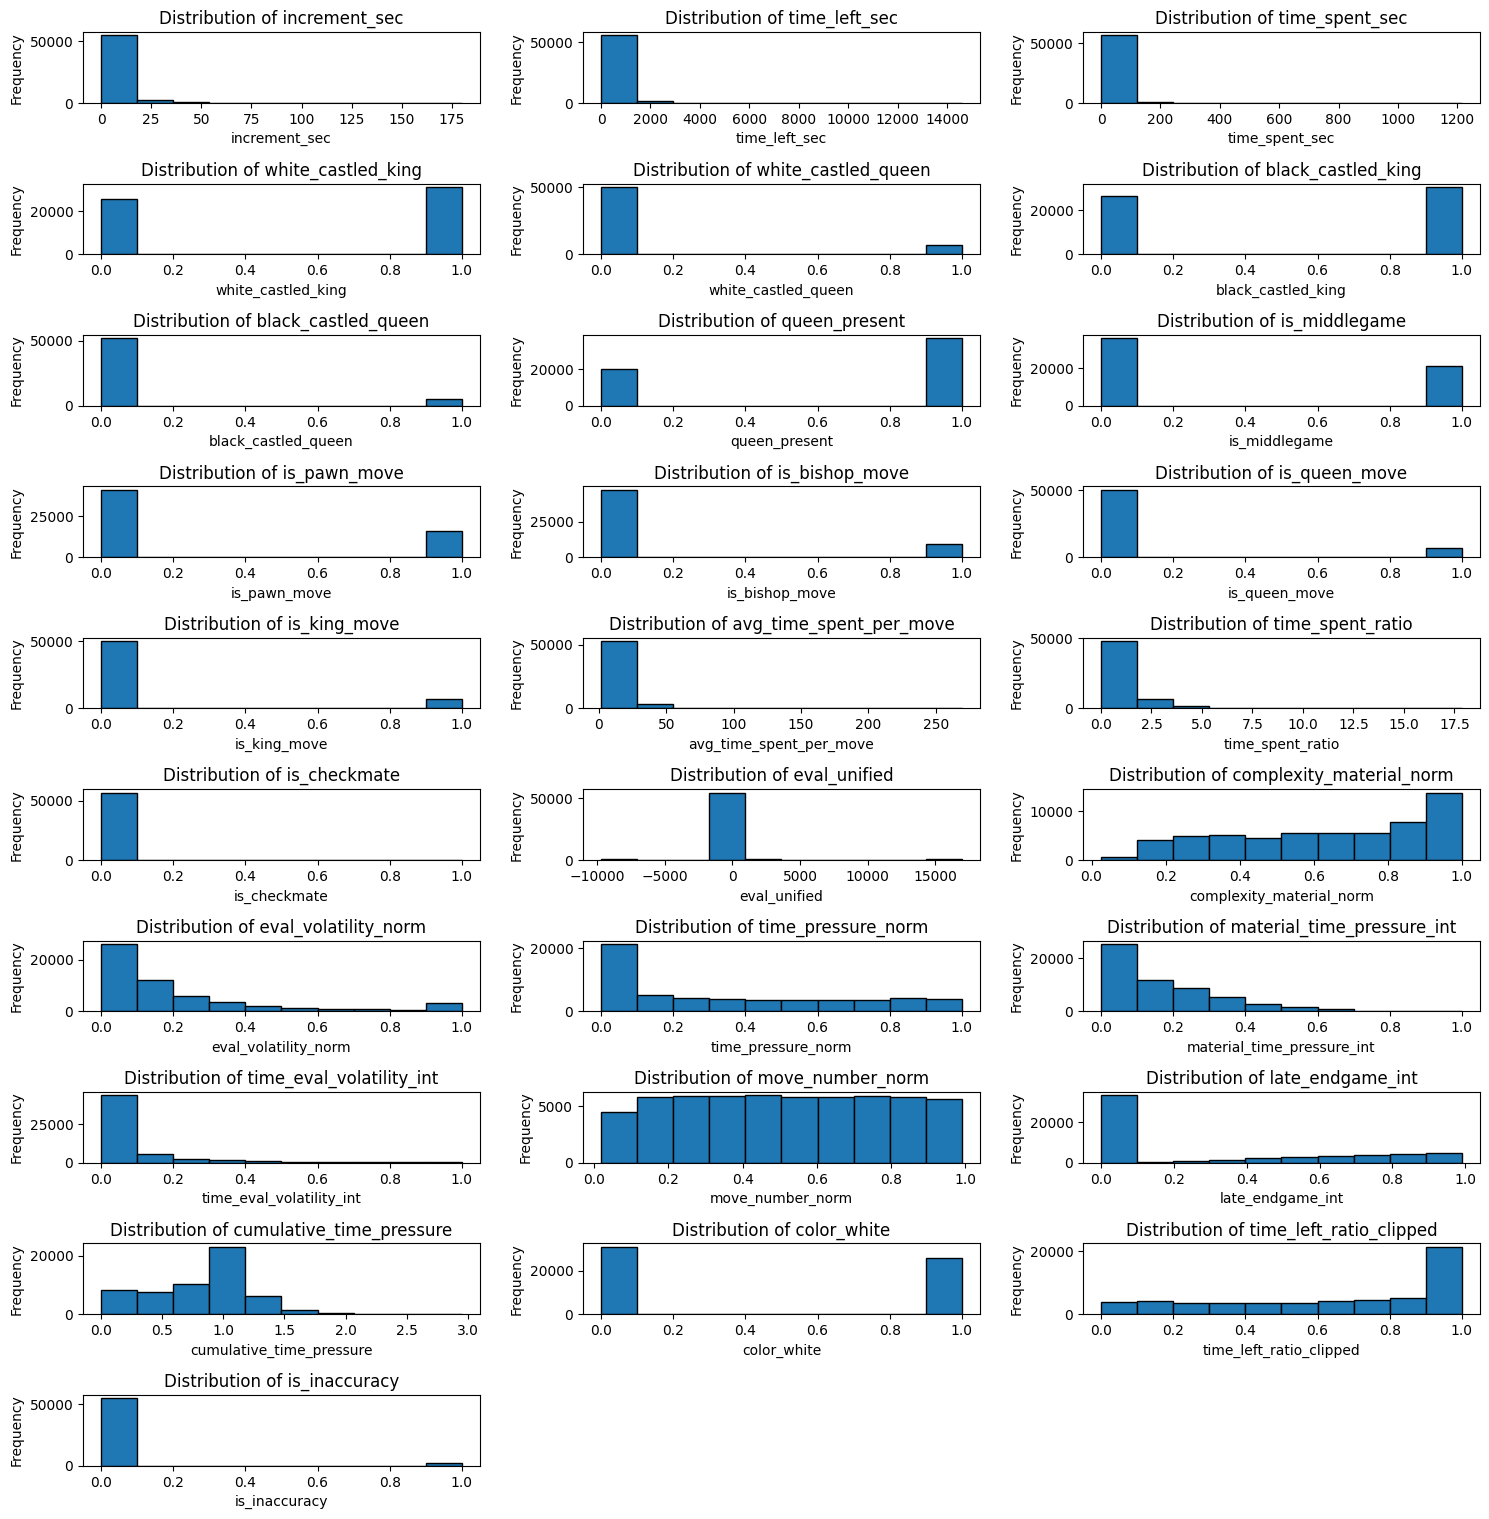

In [101]:
columns_df = train_df.columns

num_cols = len(columns_df)
n_cols = 3
n_rows = 20

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(columns_df):
    axes[i].hist(train_df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Determine scaling methods

In [102]:
X_train.columns

Index(['increment_sec', 'time_left_sec', 'time_spent_sec',
       'white_castled_king', 'white_castled_queen', 'black_castled_king',
       'black_castled_queen', 'queen_present', 'is_middlegame', 'is_pawn_move',
       'is_bishop_move', 'is_queen_move', 'is_king_move',
       'avg_time_spent_per_move', 'time_spent_ratio', 'is_checkmate',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white', 'time_left_ratio_clipped'],
      dtype='str')

In [103]:
scale_only_features = [
    'complexity_material_norm',   # roughly uniform — mild scaling benefit
    'eval_volatility_norm',       # right-skewed zero-inflated
    'time_pressure_norm',         # right-skewed
    'material_time_pressure_int', # right-skewed zero-inflated
    'time_eval_volatility_int',   # heavily zero-inflated
    'late_endgame_int',           # heavily zero-inflated
    'move_number_norm',           # roughly uniform — mild scaling benefit
    'time_left_ratio_clipped',    # left-skewed (most values near 1)
]

In [104]:
from sklearn.preprocessing import StandardScaler
import numpy as np

log_cols = [
    'increment_sec', 'time_left_sec', 'time_spent_sec',
    'avg_time_spent_per_move', 'time_spent_ratio', 'cumulative_time_pressure'
]
for col in log_cols:
    cap = X_train[col].quantile(0.95)
    X_train[col] = np.log1p(X_train[col].clip(0, cap))
    X_test[col]  = np.log1p(X_test[col].clip(0, cap))

for col in ['eval_unified']:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col]  = X_test[col].clip(lo, hi)

scale_cols = log_cols + ['eval_unified'] + scale_only_features

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

In [105]:
scaled_train_df = pd.concat([X_train, y_train], axis=1)

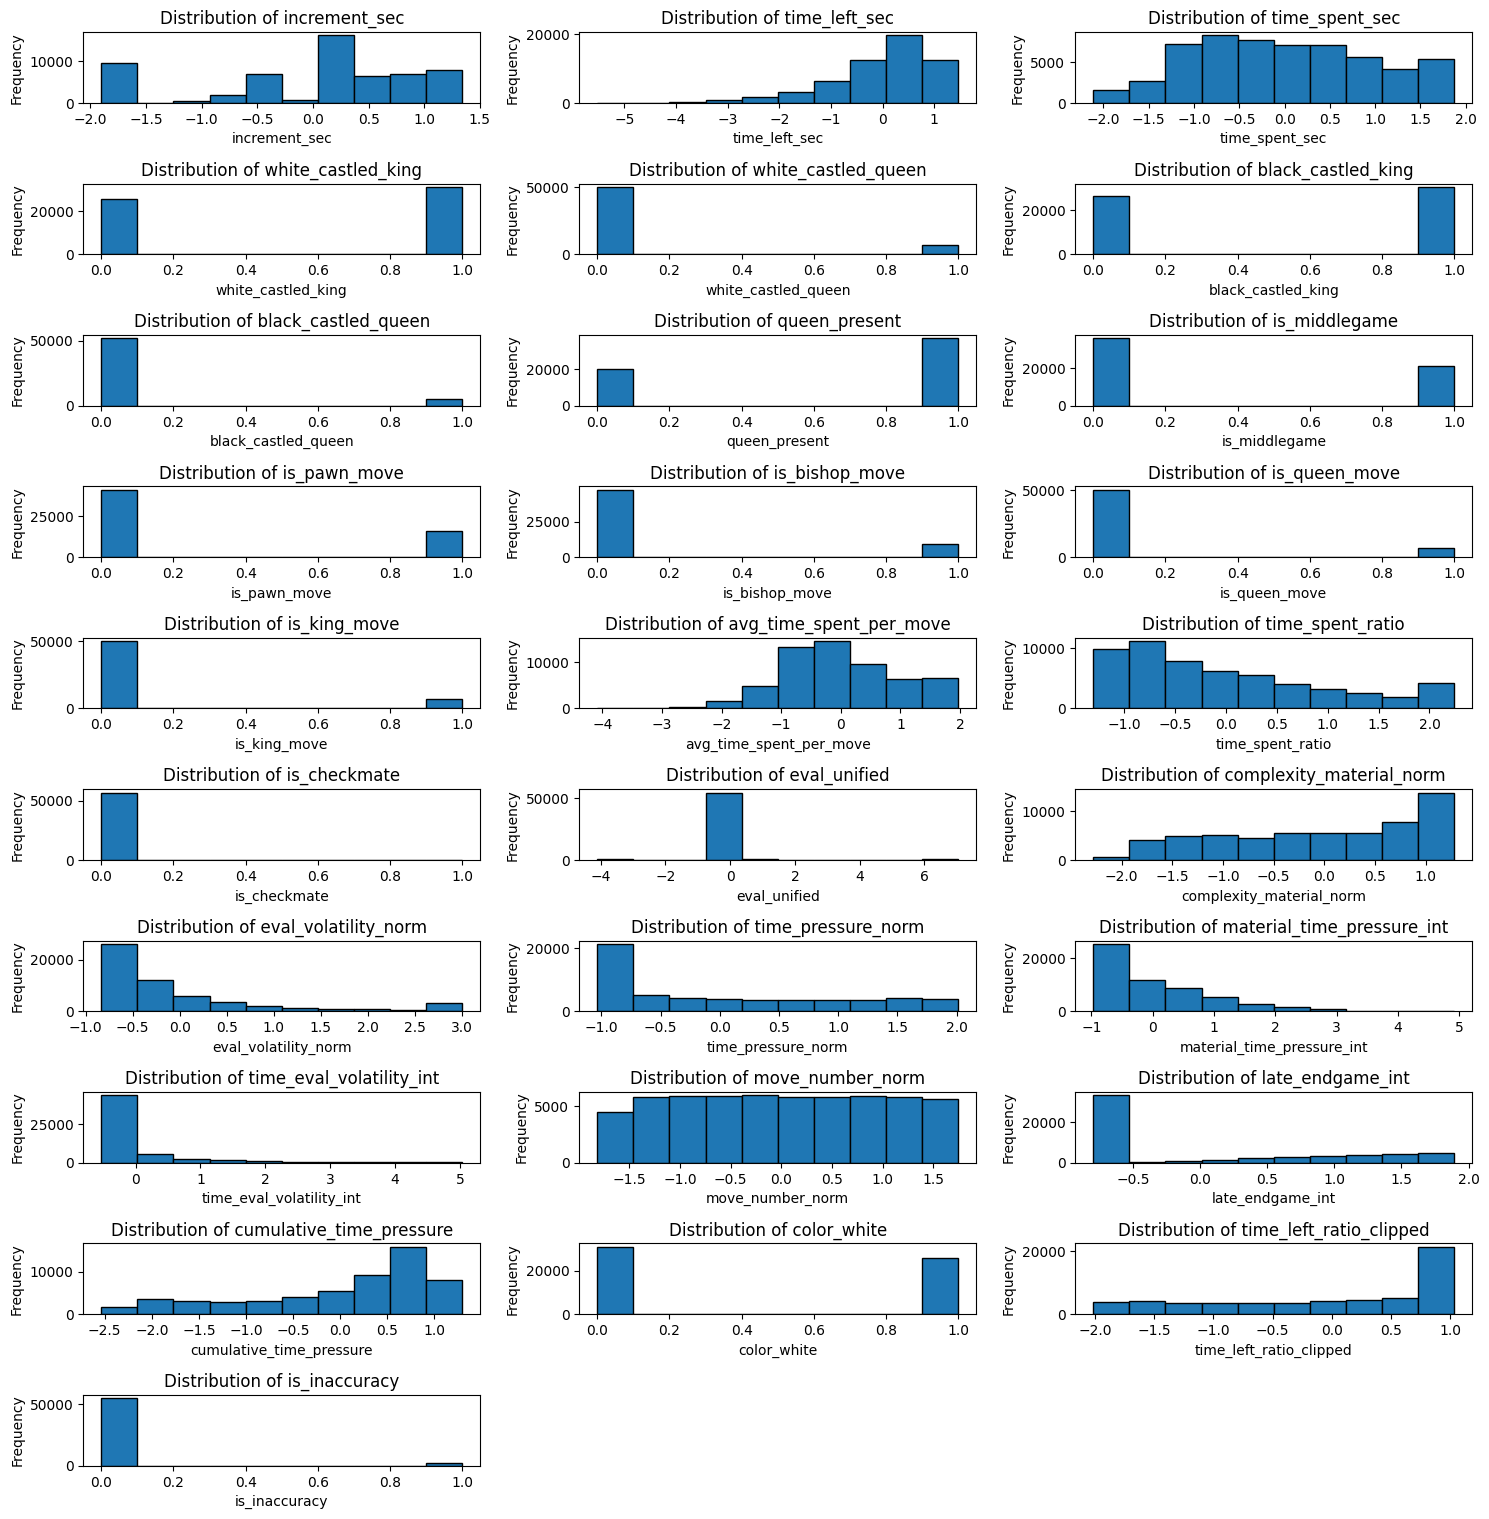

In [106]:
columns_df = scaled_train_df.columns

num_cols = len(columns_df)
n_cols = 3
n_rows = 20

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(columns_df):
    axes[i].hist(scaled_train_df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [107]:
X_train.to_csv('model_data/scaled_inaccuracy_standard_X_train.csv', index=False)
X_test.to_csv('model_data/scaled_inaccuracy_standard_X_test.csv', index=False)

In [108]:
y_train.to_csv('model_data/inaccuracy_standard_y_train.csv', index=False)
y_test.to_csv('model_data/inaccuracy_standard_y_test.csv', index=False)